In [1]:
import sys, os

sys.path.insert(0, os.path.abspath(".."))
sys.path.insert(0, os.path.abspath("helper"))

from plot_utils import (
    np,
    pd,
    plt,
    save_figure,
    load_file,
    read_config_from_csv,
    list_runs,
    FIGURE_SIZE_HALF,
    LINE_STYLE,
    GRID_STYLE,
    deep_red,
    warm_orange,
    plum,
    navy,
    bordeaux,
    mid_grey,
    cmap_bridge,
)
from analysis import align_to_rounds

In [2]:
metrics_path = "../metrics"
FIG_DIR = "../figures/evaluation/convergence"
os.makedirs(FIG_DIR, exist_ok=True)

In [3]:
PARTIAL_MAX_ROUND = 10
PARTIAL_EXT_ROUND = 20

base = os.path.join(metrics_path, "b2_partial_update_ratio")

rows_partial = []
for name, path in list_runs(base):
    if not name.startswith("r_"):
        continue

    # my run names look here like "r_050_full_mesh_seed_3" or "r_025_seed_0_fashion_mnist"
    remainder = name[2:]

    dataset = "mnist"
    if remainder.endswith("_fashion_mnist"):
        dataset = "fashion_mnist"
        remainder = remainder[:-len("_fashion_mnist")]

    ratio_digits, found_sep, remainder = remainder.partition("_")
    if not found_sep or len(ratio_digits) != 3 or not ratio_digits.isdigit():
        continue

    topo = "circulant"
    if remainder.startswith("full_mesh_"):
        topo = "full_mesh"
        remainder = remainder[len("full_mesh_"):]

    if not remainder.startswith("seed_"):
        continue
    seed_str = remainder[len("seed_"):]
    if not seed_str.isdigit():
        continue

    ratio = int(ratio_digits) / 100.0
    seed = int(seed_str)

    df = load_file(path)

    round_rows = df[df.field == "current_round"][["timestamp", "node", "value"]].copy()
    round_rows["cr"] = pd.to_numeric(round_rows.value)

    accuracy_rows = df[df.field == "aggregated_accuracy"][["timestamp", "node", "value"]].copy()
    accuracy_rows["acc"] = pd.to_numeric(accuracy_rows.value)

    merged = align_to_rounds(
        accuracy_rows, round_rows[["timestamp", "node", "cr"]]
    ).dropna(subset=["cr", "acc"])
    last_per_round = merged[merged["acc"] > 0].groupby(["node", "cr"])["acc"].last().reset_index()

    for _, row in last_per_round.iterrows():
        rows_partial.append(
            (topo, dataset, ratio, seed, row["node"], int(row["cr"]), float(row["acc"]))
        )

df_partial_all = pd.DataFrame(rows_partial, columns=["topo", "dataset", "r", "seed", "node", "round", "acc"])
df_partial_all = df_partial_all[df_partial_all["round"] <= PARTIAL_EXT_ROUND]

df_partial = df_partial_all[df_partial_all.topo == "circulant"]
node_mean_partial = df_partial.groupby(["dataset", "r", "seed", "round"])["acc"].mean().reset_index()
seed_agg_partial = (
    node_mean_partial.groupby(["dataset", "r", "round"])["acc"].agg(["mean", "min", "max", "count"]).reset_index()
)

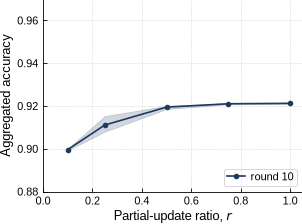

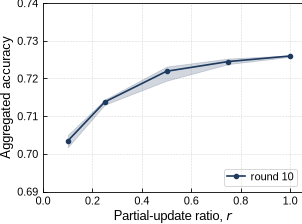

In [4]:
def plot_partial_final(dataset, ylim, out_name):
    dataset_stats = seed_agg_partial[seed_agg_partial.dataset == dataset]
    final_round10 = dataset_stats[dataset_stats["round"] == PARTIAL_MAX_ROUND].sort_values("r")
    final_round20 = dataset_stats[dataset_stats["round"] == PARTIAL_EXT_ROUND].sort_values("r")

    fig, ax = plt.subplots(figsize=FIGURE_SIZE_HALF)

    multi_seed10 = final_round10[final_round10["count"] >= 2]
    ax.fill_between(multi_seed10["r"], multi_seed10["min"], multi_seed10["max"], color=navy, alpha=0.2)
    ax.plot(
        final_round10["r"],
        final_round10["mean"],
        marker="o",
        color=navy,
        markersize=3,
        label=f"round {PARTIAL_MAX_ROUND}",
        **LINE_STYLE,
    )

    if not final_round20.empty:
        multi_seed20 = final_round20[final_round20["count"] >= 2]
        ax.fill_between(multi_seed20["r"], multi_seed20["min"], multi_seed20["max"], color=bordeaux, alpha=0.2)
        ax.plot(
            final_round20["r"],
            final_round20["mean"],
            marker="s",
            color=bordeaux,
            markersize=3,
            label=f"round {PARTIAL_EXT_ROUND}",
            **LINE_STYLE,
        )

    ax.set_xlabel(r"Partial-update ratio, $r$")
    ax.set_ylabel("Aggregated accuracy")
    ax.set_xlim(0, 1.05)
    ax.set_ylim(*ylim)
    ax.grid(**GRID_STYLE)
    ax.legend(loc="lower right", framealpha=0.9)
    fig.tight_layout()
    save_figure(fig, f"{FIG_DIR}/{out_name}")
    plt.show()


plot_partial_final("mnist", (0.88, 0.97), "partial_update_final_accuracy_mnist.pdf")
plot_partial_final("fashion_mnist", (0.69, 0.74), "partial_update_final_accuracy_fashion.pdf")

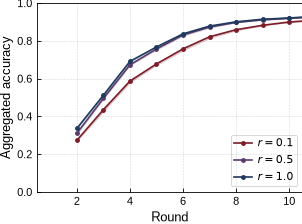

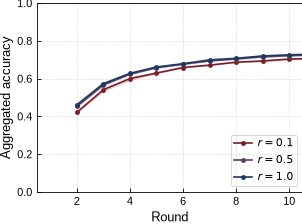

In [5]:
from matplotlib.colors import LinearSegmentedColormap

selected_r = [0.1, 0.3, 0.5, 0.7, 1.0]
cmap = LinearSegmentedColormap.from_list("bordeaux_navy", [bordeaux, cmap_bridge, navy])
colors = [cmap(i / (len(selected_r) - 1)) for i in range(len(selected_r))]


def plot_partial_round(dataset, out_name):
    dataset_stats = seed_agg_partial[seed_agg_partial.dataset == dataset]

    fig, ax = plt.subplots(figsize=FIGURE_SIZE_HALF)
    for r_val, color in zip(selected_r, colors):
        ratio_curve = dataset_stats[dataset_stats["r"] == r_val].sort_values("round")
        ratio_curve = ratio_curve[ratio_curve["round"] >= 1]
        if ratio_curve.empty:
            continue

        ax.plot(
            ratio_curve["round"],
            ratio_curve["mean"],
            color=color,
            marker="o",
            markersize=2.5,
            label=f"$r={r_val}$",
            **LINE_STYLE,
        )

        multi_seed = ratio_curve[ratio_curve["count"] >= 2]
        if not multi_seed.empty:
            ax.fill_between(multi_seed["round"], multi_seed["min"], multi_seed["max"], color=color, alpha=0.18)

    ax.set_xlabel("Round")
    ax.set_ylabel("Aggregated accuracy")
    ax.grid(**GRID_STYLE)
    ax.legend(loc="lower right", framealpha=0.9)
    ax.set_xlim(0.5, PARTIAL_MAX_ROUND + 0.5)
    ax.set_ylim(0, 1.0)
    fig.tight_layout()
    save_figure(fig, f"{FIG_DIR}/{out_name}")
    plt.show()


plot_partial_round("mnist", "partial_update_accuracy_vs_round_mnist.pdf")
plot_partial_round("fashion_mnist", "partial_update_accuracy_vs_round_fashion.pdf")

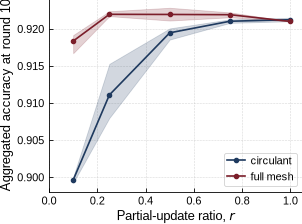

In [6]:
partial_mnist = df_partial_all[df_partial_all.dataset == "mnist"]
node_mean = partial_mnist.groupby(["topo", "r", "seed", "round"])["acc"].mean().reset_index()
stats_by_round = node_mean.groupby(["topo", "r", "round"])["acc"].agg(["mean", "min", "max", "count"]).reset_index()
final_round = stats_by_round[stats_by_round["round"] == PARTIAL_MAX_ROUND]

fig, ax = plt.subplots(figsize=FIGURE_SIZE_HALF)
for topo, color in (("circulant", navy), ("full_mesh", bordeaux)):
    topo_curve = final_round[final_round.topo == topo].sort_values("r")
    if topo_curve.empty:
        continue

    multi_seed = topo_curve[topo_curve["count"] >= 2]
    if not multi_seed.empty:
        ax.fill_between(multi_seed["r"], multi_seed["min"], multi_seed["max"], color=color, alpha=0.2)
    ax.plot(topo_curve["r"], topo_curve["mean"], marker="o", color=color, markersize=3, label=topo.replace("_", " "), **LINE_STYLE)

ax.set_xlabel(r"Partial-update ratio, $r$")
ax.set_ylabel(f"Aggregated accuracy at round {PARTIAL_MAX_ROUND}")
ax.set_xlim(0, 1.05)
ax.grid(**GRID_STYLE)
ax.legend(loc="lower right", framealpha=0.9)
fig.tight_layout()
save_figure(fig, f"{FIG_DIR}/partial_update_topo_final_mnist.pdf")
plt.show()

In [7]:
HET_DIR = os.path.join(metrics_path, "b2_het_partial_sweep")
HET_FINAL_ROUND = 10


def load_het_runs():
    rows = []
    for name, path in list_runs(HET_DIR):
        # my run names look like "a_050_r_075_seed_2"
        name_parts = name.split("_")
        if len(name_parts) != 6 or name_parts[0] != "a" or name_parts[2] != "r" or name_parts[4] != "seed":
            continue
        if not (
            len(name_parts[1]) == 3
            and name_parts[1].isdigit()
            and len(name_parts[3]) == 3
            and name_parts[3].isdigit()
            and name_parts[5].isdigit()
        ):
            continue

        alpha = int(name_parts[1]) / 100.0
        ratio = int(name_parts[3]) / 100.0
        seed = int(name_parts[5])

        df = load_file(path)

        round_rows = df[df.field == "current_round"][["timestamp", "node", "value"]].copy()
        round_rows["cr"] = pd.to_numeric(round_rows.value)

        accuracy_rows = df[df.field == "aggregated_accuracy"][["timestamp", "node", "value"]].copy()
        accuracy_rows["acc"] = pd.to_numeric(accuracy_rows.value)

        merged = align_to_rounds(
            accuracy_rows, round_rows[["timestamp", "node", "cr"]]
        ).dropna(subset=["cr", "acc"])
        last_per_round = merged[merged["acc"] > 0].groupby(["node", "cr"])["acc"].last().reset_index()

        for _, row in last_per_round.iterrows():
            rows.append((alpha, ratio, seed, row["node"], int(row["cr"]), float(row["acc"])))

    # My iid baseline (alpha=10) reuses the circulant MNIST runs analyzed above.
    iid_baseline = df_partial_all[(df_partial_all.dataset == "mnist") & (df_partial_all.topo == "circulant")]
    for _, row in iid_baseline.iterrows():
        rows.append((10.0, float(row["r"]), int(row["seed"]), row["node"], int(row["round"]), float(row["acc"])))

    return pd.DataFrame(rows, columns=["alpha", "r", "seed", "node", "round", "acc"])


df_het = load_het_runs()

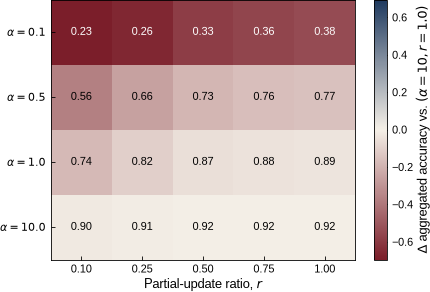

In [8]:
from matplotlib.colors import LinearSegmentedColormap

HET_ALPHAS = [0.1, 0.5, 1.0, 10.0]
HET_RS = [0.10, 0.25, 0.50, 0.75, 1.00]

final = df_het[df_het["round"] == HET_FINAL_ROUND]
grid = final.groupby(["alpha", "r"])["acc"].mean().reset_index()

acc_grid = np.full((len(HET_ALPHAS), len(HET_RS)), np.nan)

for i, a in enumerate(HET_ALPHAS):

    for j, r in enumerate(HET_RS):

        cell_rows = grid[(np.isclose(grid.alpha, a)) & (np.isclose(grid.r, r))]

        if not cell_rows.empty:
            acc_grid[i, j] = float(cell_rows["acc"].iloc[0])

baseline = acc_grid[HET_ALPHAS.index(10.0), HET_RS.index(1.00)]

if not np.isnan(baseline):
    color_limit = float(np.nanmax(np.abs(acc_grid - baseline)))
else:
    color_limit = 0.2

cmap = LinearSegmentedColormap.from_list("bordeaux_cream_navy", [bordeaux, "#F4EFE7", navy])

fig, ax = plt.subplots(figsize=(4.4, 3.0))

delta_grid = acc_grid - (baseline if not np.isnan(baseline) else 0.0)

image = ax.imshow(delta_grid, cmap=cmap, vmin=-color_limit, vmax=color_limit, aspect="auto", origin="upper")

ax.set_xticks(range(len(HET_RS)))
ax.set_xticklabels([f"{r:.2f}" for r in HET_RS])
ax.set_yticks(range(len(HET_ALPHAS)))
ax.set_yticklabels([f"$\\alpha={a}$" for a in HET_ALPHAS])
ax.set_xlabel(r"Partial-update ratio, $r$")

for i in range(acc_grid.shape[0]):

    for j in range(acc_grid.shape[1]):

        v = acc_grid[i, j]

        if not np.isnan(v):
            text_color = "white" if color_limit > 0 and abs(delta_grid[i, j]) / color_limit > 0.6 else "black"
            ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=8, color=text_color)

fig.colorbar(image, ax=ax, label=r"$\Delta$ aggregated accuracy vs. $(\alpha{=}10, r{=}1.0)$")
fig.tight_layout()
save_figure(fig, f"{FIG_DIR}/het_alpha_partial_heatmap.pdf")

plt.show()

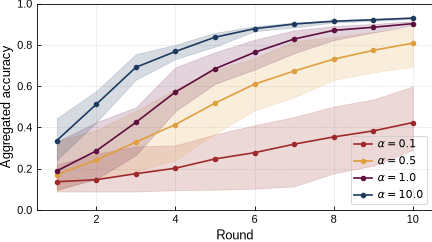

In [9]:
HET_ALPHAS = [0.1, 0.5, 1.0, 10.0]

at_full_ratio = df_het[np.isclose(df_het.r, 1.0)]
per_round = at_full_ratio.groupby(["alpha", "round"])["acc"].agg(["mean", "min", "max", "count"]).reset_index()
per_round["round"] = per_round["round"] - 1
palette = {0.1: deep_red, 0.5: warm_orange, 1.0: plum, 10.0: navy}

fig, ax = plt.subplots(figsize=(4.4, 2.5))
for a in HET_ALPHAS:
    alpha_curve = per_round[np.isclose(per_round.alpha, a)].sort_values("round")
    alpha_curve = alpha_curve[(alpha_curve["round"] >= 1) & (alpha_curve["round"] <= HET_FINAL_ROUND)]
    if alpha_curve.empty:
        continue

    color = palette.get(a, mid_grey)
    ax.plot(alpha_curve["round"], alpha_curve["mean"], color=color, marker="o", markersize=3, label=rf"$\alpha={a}$", **LINE_STYLE)

    multi_seed = alpha_curve[alpha_curve["count"] >= 2]
    if not multi_seed.empty:
        ax.fill_between(multi_seed["round"], multi_seed["min"], multi_seed["max"], color=color, alpha=0.18)

ax.set_xlabel("Round")
ax.set_ylabel("Aggregated accuracy")
ax.grid(**GRID_STYLE)

ax.legend(loc="lower right", framealpha=0.9)
ax.set_xlim(0.5, HET_FINAL_ROUND + 0.5)
ax.set_ylim(0, 1.0)

fig.tight_layout()
save_figure(fig, f"{FIG_DIR}/het_alpha_convergence.pdf")

plt.show()